<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/Phase2/Stations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# $O_{3}$

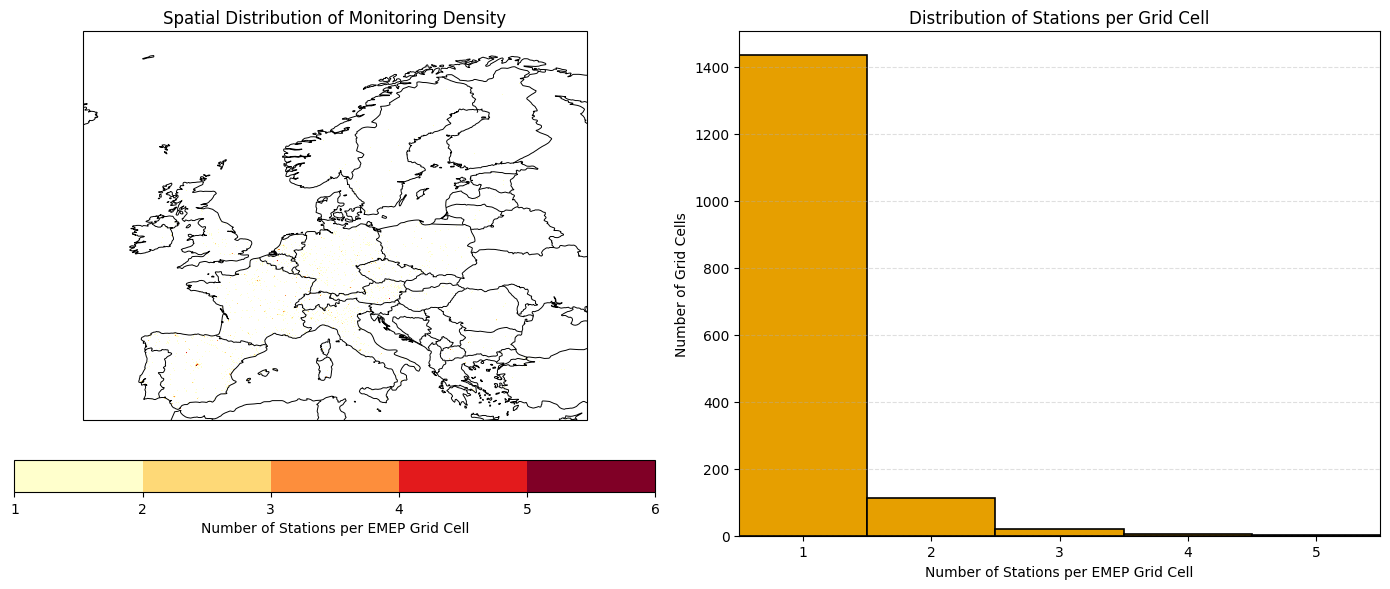

Mean stations per active cell: 1.1099809281627464
Median stations per active cell: 1.0
Max stations in one cell: 5
Total active grid cells: 1573


In [53]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ======================================================
#  Load EMEP grid
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")
lat = ds["lat"].values
lon = ds["lon"].values

lon_grid, lat_grid = np.meshgrid(lon, lat)

# ======================================================
#  Load stations
# ======================================================
stations = pd.read_csv("yearly_O3_2015.csv")

stations = stations[
    (stations["Latitude"] >= lat.min()) &
    (stations["Latitude"] <= lat.max()) &
    (stations["Longitude"] >= lon.min()) &
    (stations["Longitude"] <= lon.max())
].copy()

# ======================================================
# Assign nearest grid cell
# ======================================================
lat_idx = np.abs(lat[:, None] - stations["Latitude"].values).argmin(axis=0)
lon_idx = np.abs(lon[:, None] - stations["Longitude"].values).argmin(axis=0)

# ======================================================
# Count stations per grid cell
# ======================================================
count_grid = np.zeros((len(lat), len(lon)))

for i, j in zip(lat_idx, lon_idx):
    count_grid[i, j] += 1

masked_count_grid = np.ma.masked_where(count_grid == 0, count_grid)

cell_counts = count_grid[count_grid > 0]
max_val = int(cell_counts.max())

# ======================================================
# Create Figure with 2 Panels
# ======================================================
fig = plt.figure(figsize=(14, 6))

# =======================
# LEFT: GRID MAP
# =======================
ax_map = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())

ax_map.set_extent([-15, 35, 35, 72])

ax_map.add_feature(cfeature.BORDERS, linewidth=0.7)
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.7)

bounds = np.arange(1, max_val + 2)
norm = mcolors.BoundaryNorm(bounds, plt.cm.YlOrRd.N)

pcm = ax_map.pcolormesh(
    lon_grid,
    lat_grid,
    masked_count_grid,
    cmap="YlOrRd",
    norm=norm,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(pcm, ax=ax_map, orientation="horizontal", pad=0.08)
cbar.set_label("Number of Stations per EMEP Grid Cell")

ax_map.set_title("Spatial Distribution of Monitoring Density")

# =======================
# RIGHT: HISTOGRAM
# =======================
ax_hist = plt.subplot(1, 2, 2)

bins = np.arange(1, max_val + 2) - 0.5

ax_hist.hist(
    cell_counts,
    bins=bins,
    color="#E69F00",
    edgecolor="black",
    linewidth=1.2
)

ax_hist.set_xlim(0.5, max_val + 0.5)
ax_hist.set_ylim(bottom=0)

ax_hist.set_xticks(range(1, max_val + 1))

ax_hist.set_xlabel("Number of Stations per EMEP Grid Cell")
ax_hist.set_ylabel("Number of Grid Cells")
ax_hist.set_title("Distribution of Stations per Grid Cell")

ax_hist.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# Diagnostics
# ======================================================
print("Mean stations per active cell:", np.mean(cell_counts))
print("Median stations per active cell:", np.median(cell_counts))
print("Max stations in one cell:", max_val)
print("Total active grid cells:", len(cell_counts))

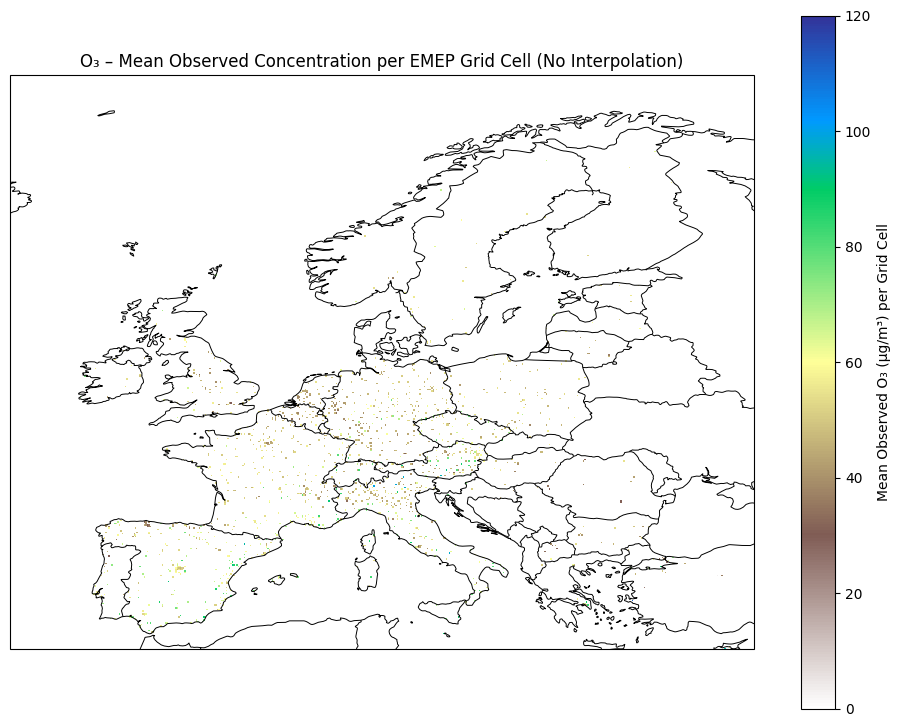

In [51]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ======================================================
#  Load EMEP grid
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")
lat = ds["lat"].values
lon = ds["lon"].values

lon_grid, lat_grid = np.meshgrid(lon, lat)

# ======================================================
#  Load stations
# ======================================================
stations = pd.read_csv("yearly_O3_2015.csv")

stations = stations[
    (stations["Latitude"] >= lat.min()) &
    (stations["Latitude"] <= lat.max()) &
    (stations["Longitude"] >= lon.min()) &
    (stations["Longitude"] <= lon.max())
].copy()

# ======================================================
#  Assign nearest grid cell
# ======================================================
lat_idx = np.abs(lat[:, None] - stations["Latitude"].values).argmin(axis=0)
lon_idx = np.abs(lon[:, None] - stations["Longitude"].values).argmin(axis=0)

stations["lat_idx"] = lat_idx
stations["lon_idx"] = lon_idx

# ======================================================
# Compute mean per grid cell
# ======================================================
mean_grid = np.full((len(lat), len(lon)), np.nan)

grouped = stations.groupby(["lat_idx", "lon_idx"])["Average"].mean()

for (i, j), value in grouped.items():
    mean_grid[int(i), int(j)] = value

# ======================================================
#  Plot (Fixed Color Scale 0–120)
# ======================================================
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-15, 35, 35, 72])

ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)

pcm = ax.pcolormesh(
    lon_grid,
    lat_grid,
    mean_grid,
    cmap="terrain_r",
    vmin=0,
    vmax=120,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label("Mean Observed O₃ (µg/m³) per Grid Cell")

plt.title("O₃ – Mean Observed Concentration per EMEP Grid Cell (No Interpolation)")
plt.show()

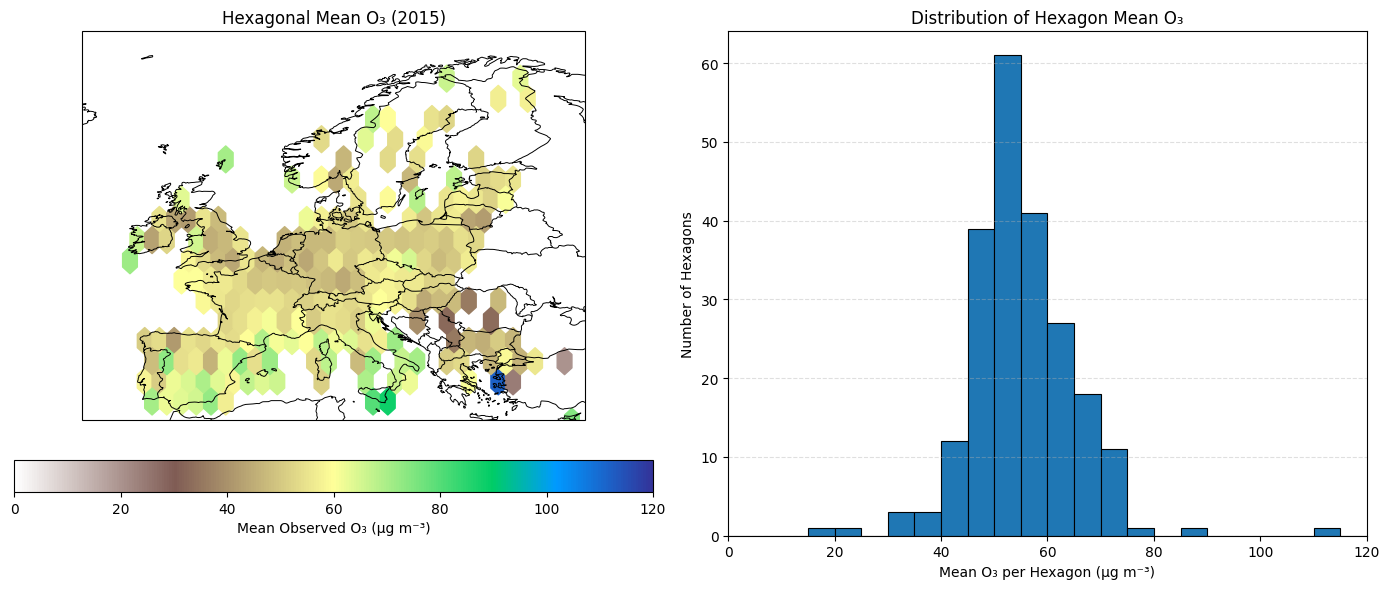

Mean of hex means: 55.23637500924401
Median of hex means: 54.4825
Min hex mean: 19.8565
Max hex mean: 111.837


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:820: UserWarning:




In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ======================================================
# Load stations
# ======================================================
stations = pd.read_csv("yearly_O3_2015.csv")

vmin = 0
vmax = 120

# ======================================================
# Create figure with 2 panels
# ======================================================
fig = plt.figure(figsize=(14, 6))

# =======================
# LEFT: Hexbin Map
# =======================
ax_map = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())

ax_map.set_extent([-15, 35, 35, 72])

ax_map.add_feature(cfeature.BORDERS, linewidth=0.7)
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.7)

hb = ax_map.hexbin(
    stations["Longitude"],
    stations["Latitude"],
    C=stations["Average"],
    reduce_C_function=np.mean,
    gridsize=45,
    cmap="terrain_r",
    vmin=vmin,
    vmax=vmax,
    mincnt=1,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(hb, ax=ax_map, orientation="horizontal", pad=0.08)
cbar.set_label("Mean Observed O₃ (µg m⁻³)")

ax_map.set_title("Hexagonal Mean O₃ (2015)")

# =======================
# RIGHT: Histogram
# =======================
hex_means = hb.get_array()

ax_hist = plt.subplot(1, 2, 2)

bins = np.linspace(vmin, vmax, 25)

ax_hist.hist(
    hex_means,
    bins=bins,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.8
)

ax_hist.set_xlim(vmin, vmax)
ax_hist.set_ylim(bottom=0)

ax_hist.set_xlabel("Mean O₃ per Hexagon (µg m⁻³)")
ax_hist.set_ylabel("Number of Hexagons")
ax_hist.set_title("Distribution of Hexagon Mean O₃")

ax_hist.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# Diagnostics
# ======================================================
print("Mean of hex means:", np.mean(hex_means))
print("Median of hex means:", np.median(hex_means))
print("Min hex mean:", np.min(hex_means))
print("Max hex mean:", np.max(hex_means))

$NO_{2}$

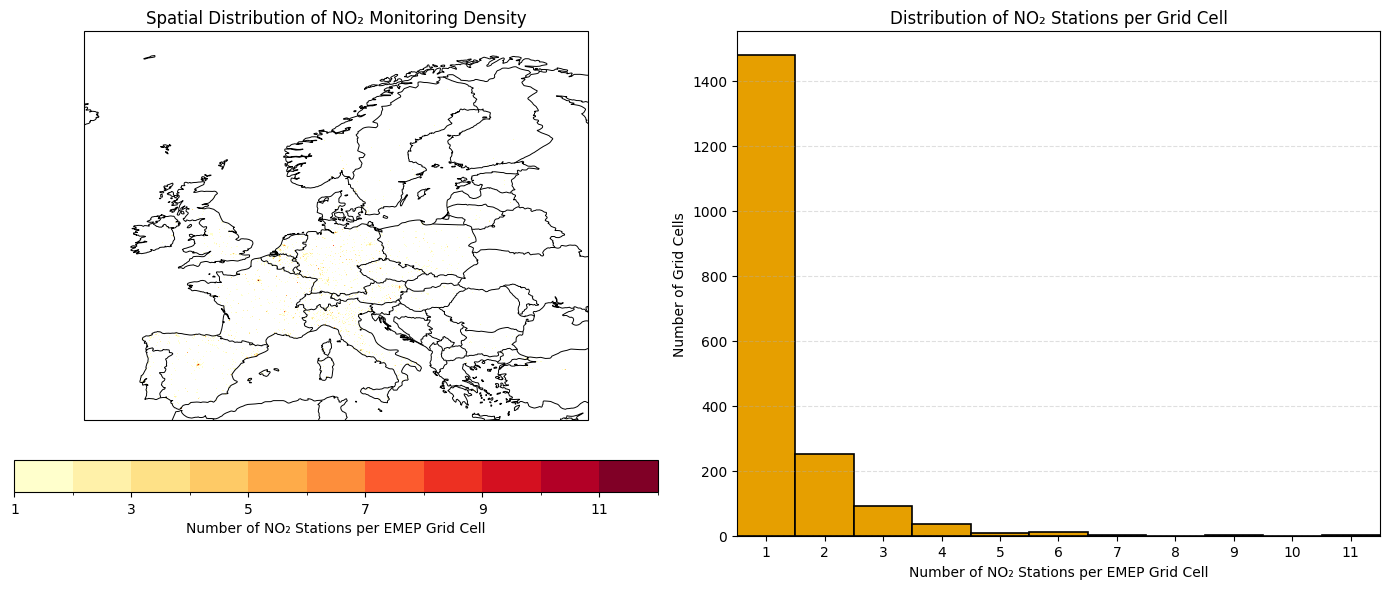

Mean stations per active cell: 1.3533794571580628
Median stations per active cell: 1.0
Max stations in one cell: 11
Total active grid cells: 1879


In [54]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ======================================================
#  Load EMEP grid
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")
lat = ds["lat"].values
lon = ds["lon"].values

lon_grid, lat_grid = np.meshgrid(lon, lat)

# ======================================================
#  Load NO2 stations
# ======================================================
stations = pd.read_csv("/content/yearly_NO2_2015.csv")

# Keep only stations inside EMEP domain
stations = stations[
    (stations["Latitude"] >= lat.min()) &
    (stations["Latitude"] <= lat.max()) &
    (stations["Longitude"] >= lon.min()) &
    (stations["Longitude"] <= lon.max())
].copy()

# ======================================================
# Assign nearest grid cell
# ======================================================
lat_idx = np.abs(lat[:, None] - stations["Latitude"].values).argmin(axis=0)
lon_idx = np.abs(lon[:, None] - stations["Longitude"].values).argmin(axis=0)

# ======================================================
# Count stations per grid cell
# ======================================================
count_grid = np.zeros((len(lat), len(lon)))

for i, j in zip(lat_idx, lon_idx):
    count_grid[i, j] += 1

masked_count_grid = np.ma.masked_where(count_grid == 0, count_grid)

cell_counts = count_grid[count_grid > 0]
max_val = int(cell_counts.max())

# ======================================================
# Create Figure with 2 Panels
# ======================================================
fig = plt.figure(figsize=(14, 6))

# =======================
# LEFT: GRID MAP
# =======================
ax_map = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax_map.set_extent([-15, 35, 35, 72])

ax_map.add_feature(cfeature.BORDERS, linewidth=0.7)
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.7)

bounds = np.arange(1, max_val + 2)
norm = mcolors.BoundaryNorm(bounds, plt.cm.YlOrRd.N)

pcm = ax_map.pcolormesh(
    lon_grid,
    lat_grid,
    masked_count_grid,
    cmap="YlOrRd",
    norm=norm,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(pcm, ax=ax_map, orientation="horizontal", pad=0.08)
cbar.set_label("Number of NO₂ Stations per EMEP Grid Cell")

ax_map.set_title("Spatial Distribution of NO₂ Monitoring Density")

# =======================
# RIGHT: HISTOGRAM
# =======================
ax_hist = plt.subplot(1, 2, 2)

bins = np.arange(1, max_val + 2) - 0.5

ax_hist.hist(
    cell_counts,
    bins=bins,
    color="#E69F00",
    edgecolor="black",
    linewidth=1.2
)

ax_hist.set_xlim(0.5, max_val + 0.5)
ax_hist.set_ylim(bottom=0)

ax_hist.set_xticks(range(1, max_val + 1))

ax_hist.set_xlabel("Number of NO₂ Stations per EMEP Grid Cell")
ax_hist.set_ylabel("Number of Grid Cells")
ax_hist.set_title("Distribution of NO₂ Stations per Grid Cell")

ax_hist.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# Diagnostics
# ======================================================
print("Mean stations per active cell:", np.mean(cell_counts))
print("Median stations per active cell:", np.median(cell_counts))
print("Max stations in one cell:", max_val)
print("Total active grid cells:", len(cell_counts))

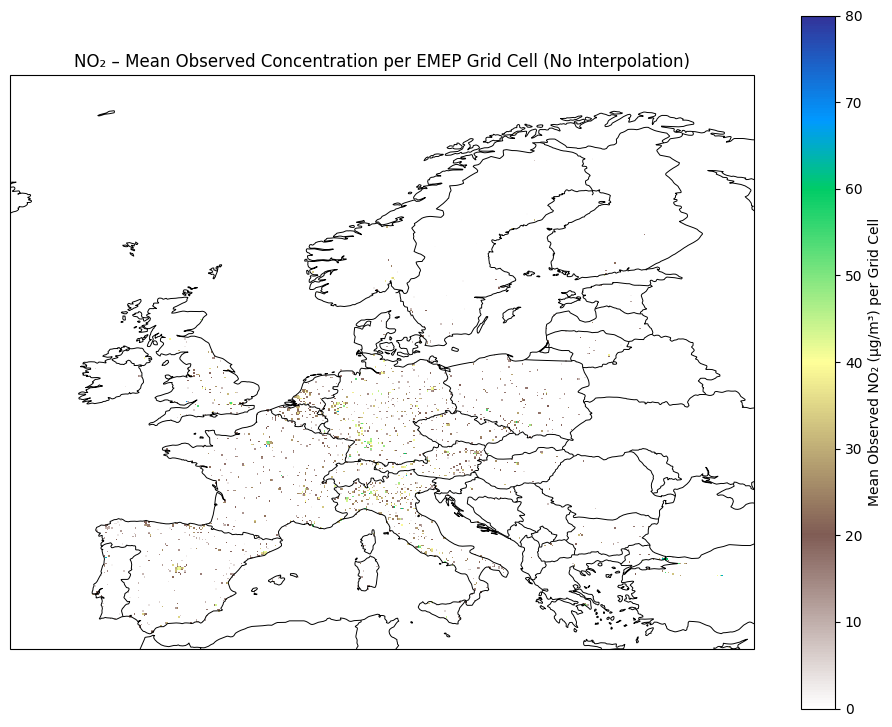

In [55]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ======================================================
#  Load EMEP grid
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")
lat = ds["lat"].values
lon = ds["lon"].values

lon_grid, lat_grid = np.meshgrid(lon, lat)

# ======================================================
#  Load NO2 stations
# ======================================================
stations = pd.read_csv("/content/yearly_NO2_2015.csv")

stations = stations[
    (stations["Latitude"] >= lat.min()) &
    (stations["Latitude"] <= lat.max()) &
    (stations["Longitude"] >= lon.min()) &
    (stations["Longitude"] <= lon.max())
].copy()

# ======================================================
#  Assign nearest grid cell
# ======================================================
lat_idx = np.abs(lat[:, None] - stations["Latitude"].values).argmin(axis=0)
lon_idx = np.abs(lon[:, None] - stations["Longitude"].values).argmin(axis=0)

stations["lat_idx"] = lat_idx
stations["lon_idx"] = lon_idx

# ======================================================
#  Compute mean per grid cell
# ======================================================
mean_grid = np.full((len(lat), len(lon)), np.nan)

grouped = stations.groupby(["lat_idx", "lon_idx"])["Average"].mean()

for (i, j), value in grouped.items():
    mean_grid[int(i), int(j)] = value

# ======================================================
#  Plot (Fixed Color Scale for NO2)
# ======================================================
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-15, 35, 35, 72])

ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)

pcm = ax.pcolormesh(
    lon_grid,
    lat_grid,
    mean_grid,
    cmap="terrain_r",
    vmin=0,
    vmax=80,  # Adjusted scale for NO2 (more realistic than 0–120)
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label("Mean Observed NO₂ (µg/m³) per Grid Cell")

plt.title("NO₂ – Mean Observed Concentration per EMEP Grid Cell (No Interpolation)")
plt.show()

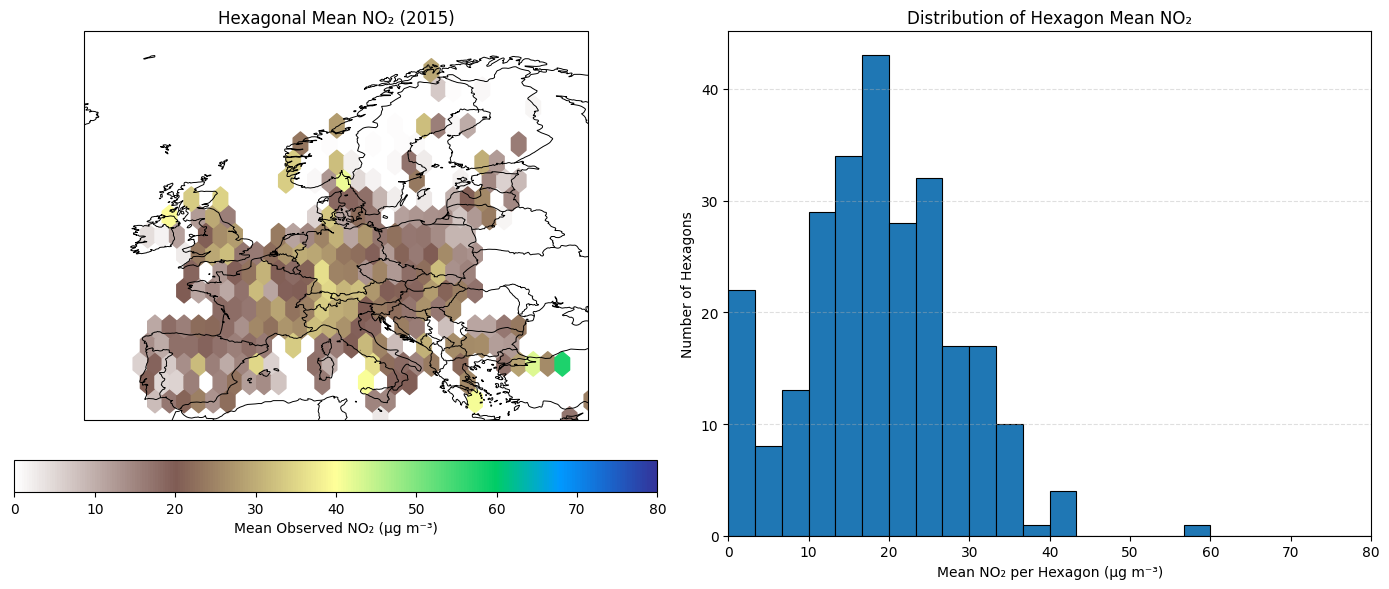

Mean of hex means: 18.730365486068244
Median of hex means: 18.0464
Min hex mean: 0.254
Max hex mean: 57.59616666666667


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:820: UserWarning:




In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ======================================================
# Load NO2 stations
# ======================================================
stations = pd.read_csv("/content/yearly_NO2_2015.csv")

vmin = 0
vmax = 80   # More realistic upper bound for annual NO2

# ======================================================
# Create figure with 2 panels
# ======================================================
fig = plt.figure(figsize=(14, 6))

# =======================
# LEFT: Hexbin Map
# =======================
ax_map = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())

ax_map.set_extent([-15, 35, 35, 72])

ax_map.add_feature(cfeature.BORDERS, linewidth=0.7)
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.7)

hb = ax_map.hexbin(
    stations["Longitude"],
    stations["Latitude"],
    C=stations["Average"],
    reduce_C_function=np.mean,
    gridsize=45,
    cmap="terrain_r",
    vmin=vmin,
    vmax=vmax,
    mincnt=1,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(hb, ax=ax_map, orientation="horizontal", pad=0.08)
cbar.set_label("Mean Observed NO₂ (µg m⁻³)")

ax_map.set_title("Hexagonal Mean NO₂ (2015)")

# =======================
# RIGHT: Histogram
# =======================
hex_means = hb.get_array()

ax_hist = plt.subplot(1, 2, 2)

bins = np.linspace(vmin, vmax, 25)

ax_hist.hist(
    hex_means,
    bins=bins,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.8
)

ax_hist.set_xlim(vmin, vmax)
ax_hist.set_ylim(bottom=0)

ax_hist.set_xlabel("Mean NO₂ per Hexagon (µg m⁻³)")
ax_hist.set_ylabel("Number of Hexagons")
ax_hist.set_title("Distribution of Hexagon Mean NO₂")

ax_hist.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# Diagnostics
# ======================================================
print("Mean of hex means:", np.mean(hex_means))
print("Median of hex means:", np.median(hex_means))
print("Min hex mean:", np.min(hex_means))
print("Max hex mean:", np.max(hex_means))

$PM_{2.5}$

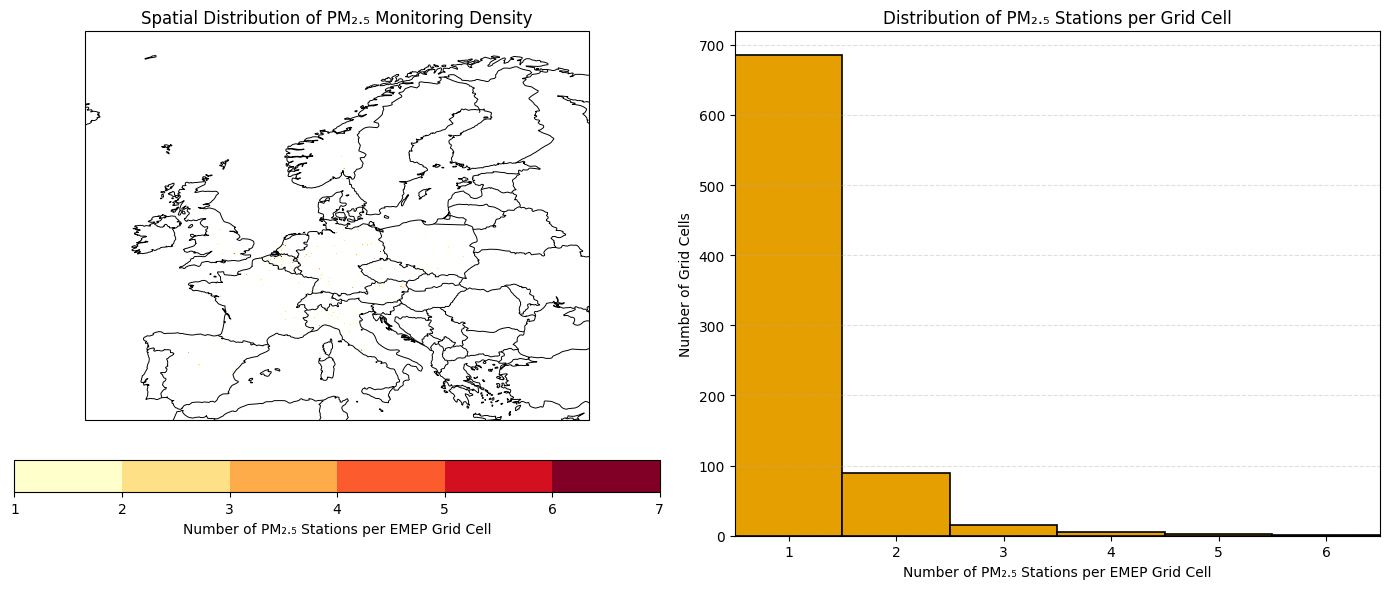

Mean stations per active cell: 1.18671679197995
Median stations per active cell: 1.0
Max stations in one cell: 6
Total active grid cells: 798


In [59]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ======================================================
#  Load EMEP grid
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")
lat = ds["lat"].values
lon = ds["lon"].values

lon_grid, lat_grid = np.meshgrid(lon, lat)

# ======================================================
#  Load PM25 stations
# ======================================================
stations = pd.read_csv("/content/yearly_PM25_2015.csv")

# Keep only stations inside EMEP domain
stations = stations[
    (stations["Latitude"] >= lat.min()) &
    (stations["Latitude"] <= lat.max()) &
    (stations["Longitude"] >= lon.min()) &
    (stations["Longitude"] <= lon.max())
].copy()

# ======================================================
# Assign nearest grid cell
# ======================================================
lat_idx = np.abs(lat[:, None] - stations["Latitude"].values).argmin(axis=0)
lon_idx = np.abs(lon[:, None] - stations["Longitude"].values).argmin(axis=0)

# ======================================================
# Count stations per grid cell
# ======================================================
count_grid = np.zeros((len(lat), len(lon)))

for i, j in zip(lat_idx, lon_idx):
    count_grid[i, j] += 1

masked_count_grid = np.ma.masked_where(count_grid == 0, count_grid)

cell_counts = count_grid[count_grid > 0]
max_val = int(cell_counts.max())

# ======================================================
# Create Figure with 2 Panels
# ======================================================
fig = plt.figure(figsize=(14, 6))

# =======================
# LEFT: GRID MAP
# =======================
ax_map = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax_map.set_extent([-15, 35, 35, 72])

ax_map.add_feature(cfeature.BORDERS, linewidth=0.7)
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.7)

bounds = np.arange(1, max_val + 2)
norm = mcolors.BoundaryNorm(bounds, plt.cm.YlOrRd.N)

pcm = ax_map.pcolormesh(
    lon_grid,
    lat_grid,
    masked_count_grid,
    cmap="YlOrRd",
    norm=norm,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(pcm, ax=ax_map, orientation="horizontal", pad=0.08)
cbar.set_label("Number of PM₂.₅ Stations per EMEP Grid Cell")

ax_map.set_title("Spatial Distribution of PM₂.₅ Monitoring Density")

# =======================
# RIGHT: HISTOGRAM
# =======================
ax_hist = plt.subplot(1, 2, 2)

bins = np.arange(1, max_val + 2) - 0.5

ax_hist.hist(
    cell_counts,
    bins=bins,
    color="#E69F00",
    edgecolor="black",
    linewidth=1.2
)

ax_hist.set_xlim(0.5, max_val + 0.5)
ax_hist.set_ylim(bottom=0)

ax_hist.set_xticks(range(1, max_val + 1))

ax_hist.set_xlabel("Number of PM₂.₅ Stations per EMEP Grid Cell")
ax_hist.set_ylabel("Number of Grid Cells")
ax_hist.set_title("Distribution of PM₂.₅ Stations per Grid Cell")

ax_hist.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# Diagnostics
# ======================================================
print("Mean stations per active cell:", np.mean(cell_counts))
print("Median stations per active cell:", np.median(cell_counts))
print("Max stations in one cell:", max_val)
print("Total active grid cells:", len(cell_counts))

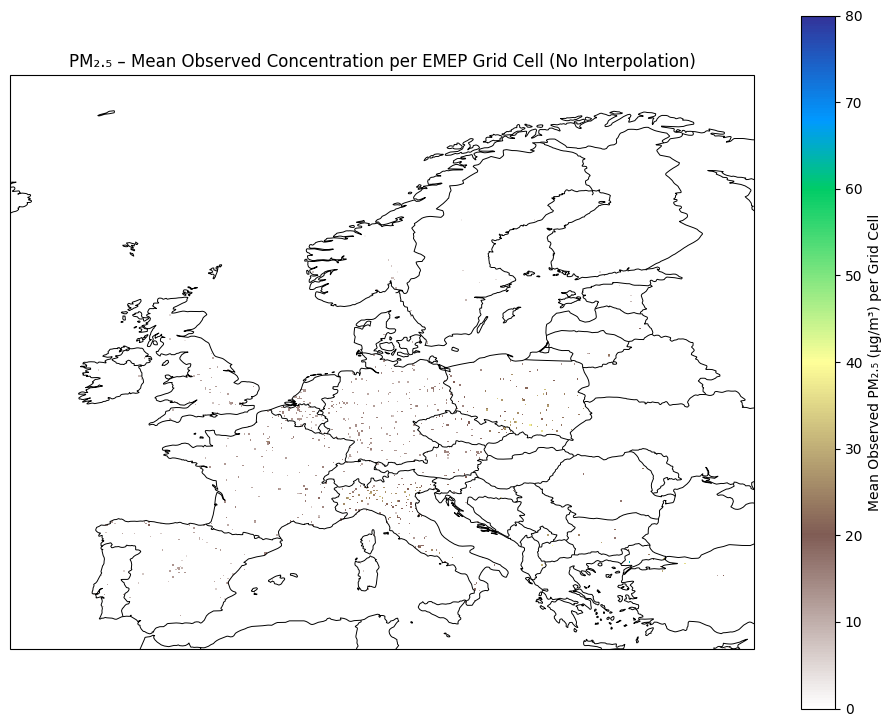

In [60]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ======================================================
#  Load EMEP grid
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")
lat = ds["lat"].values
lon = ds["lon"].values

lon_grid, lat_grid = np.meshgrid(lon, lat)

# ======================================================
#  Load PM25 stations
# ======================================================
stations = pd.read_csv("/content/yearly_PM25_2015.csv")

stations = stations[
    (stations["Latitude"] >= lat.min()) &
    (stations["Latitude"] <= lat.max()) &
    (stations["Longitude"] >= lon.min()) &
    (stations["Longitude"] <= lon.max())
].copy()

# ======================================================
#  Assign nearest grid cell
# ======================================================
lat_idx = np.abs(lat[:, None] - stations["Latitude"].values).argmin(axis=0)
lon_idx = np.abs(lon[:, None] - stations["Longitude"].values).argmin(axis=0)

stations["lat_idx"] = lat_idx
stations["lon_idx"] = lon_idx

# ======================================================
#  Compute mean per grid cell
# ======================================================
mean_grid = np.full((len(lat), len(lon)), np.nan)

grouped = stations.groupby(["lat_idx", "lon_idx"])["Average"].mean()

for (i, j), value in grouped.items():
    mean_grid[int(i), int(j)] = value

# ======================================================
#  Plot (Fixed Color Scale for PM2.5)
# ======================================================
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-15, 35, 35, 72])

ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)

pcm = ax.pcolormesh(
    lon_grid,
    lat_grid,
    mean_grid,
    cmap="terrain_r",
    vmin=0,
    vmax=80,   # Realistic annual PM2.5 range
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label("Mean Observed PM₂.₅ (µg/m³) per Grid Cell")

plt.title("PM₂.₅ – Mean Observed Concentration per EMEP Grid Cell (No Interpolation)")
plt.show()

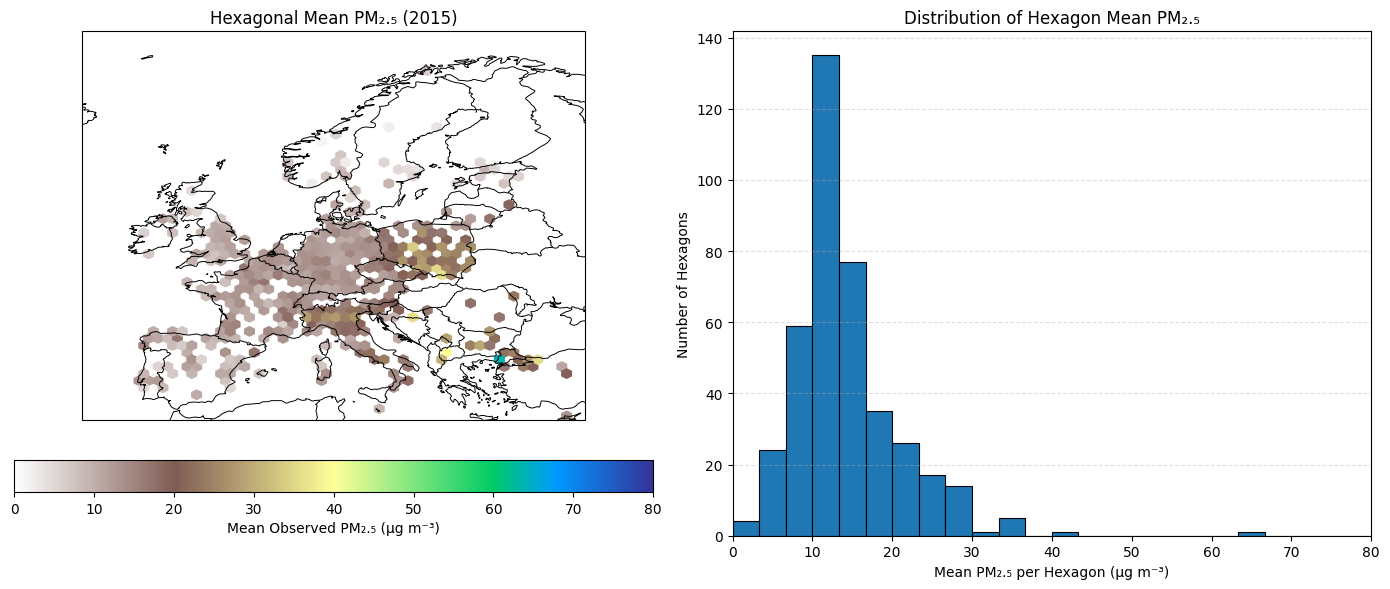

Mean of hex means: 14.159883691371284
Median of hex means: 12.819285714285714
Min hex mean: 1.512
Max hex mean: 63.823


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:820: UserWarning:




In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ======================================================
# Load PM25 stations
# ======================================================
stations = pd.read_csv("/content/yearly_PM25_2015.csv")

vmin = 0
vmax = 80   # Typical annual PM2.5 range in Europe

# ======================================================
# Create figure with 2 panels
# ======================================================
fig = plt.figure(figsize=(14, 6))

# =======================
# LEFT: Hexbin Map
# =======================
ax_map = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())

ax_map.set_extent([-15, 35, 35, 72])

ax_map.add_feature(cfeature.BORDERS, linewidth=0.7)
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.7)

hb = ax_map.hexbin(
    stations["Longitude"],
    stations["Latitude"],
    C=stations["Average"],
    reduce_C_function=np.mean,
    gridsize=45,
    cmap="terrain_r",
    vmin=vmin,
    vmax=vmax,
    mincnt=1,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(hb, ax=ax_map, orientation="horizontal", pad=0.08)
cbar.set_label("Mean Observed PM₂.₅ (µg m⁻³)")

ax_map.set_title("Hexagonal Mean PM₂.₅ (2015)")

# =======================
# RIGHT: Histogram
# =======================
hex_means = hb.get_array()

ax_hist = plt.subplot(1, 2, 2)

bins = np.linspace(vmin, vmax, 25)

ax_hist.hist(
    hex_means,
    bins=bins,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.8
)

ax_hist.set_xlim(vmin, vmax)
ax_hist.set_ylim(bottom=0)

ax_hist.set_xlabel("Mean PM₂.₅ per Hexagon (µg m⁻³)")
ax_hist.set_ylabel("Number of Hexagons")
ax_hist.set_title("Distribution of Hexagon Mean PM₂.₅")

ax_hist.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# Diagnostics
# ======================================================
print("Mean of hex means:", np.mean(hex_means))
print("Median of hex means:", np.median(hex_means))
print("Min hex mean:", np.min(hex_means))
print("Max hex mean:", np.max(hex_means))